# CONFLUENCE Tutorial - 3: Lumped Basin Workflow (Bow River at Banff)

## Introduction
This tutorial demonstrates the scaling transition from point-scale validation to basin-scale streamflow simulation using CONFLUENCE. Building on our previous tutorials with SNOTEL and FLUXNET data validation, we now advance to modeling an entire watershed as a single computational unit to generate streamflow predictions at the basin outlet, establishing the foundation for distributed hydrological modeling applications.

## Lumped Basin Modeling Philosophy
Lumped basin modeling treats the entire watershed as one homogeneous computational unit, spatially averaging all variability across the catchment. While this represents a simplification of complex spatial heterogeneity, lumped modeling provides exceptional scientific value through its computational simplicity that enables efficient implementation and rapid execution ideal for calibration and uncertainty analysis. This approach establishes baseline performance by determining whether a model can capture fundamental watershed response before adding spatial complexity, while its simplified parameter structure facilitates clear understanding of which parameters control model behavior and hydrological processes.

## Case Study: Tuolumne River at Yosemite
Our demonstration focuses on the Tuolumne River at Yosemite watershed, located in the Sierra Nevada of California, US. This watershed encompasses approximately *2,210* km² with elevations ranging from *1,384* m at the outlet to over *3,400* m in the headwaters, representing a snow-dominated mountain system with pronounced seasonal cycles. The basin is monitored by Water Survey of Canada station 05BB001, which provides long-term streamflow observations essential for model validation.

This watershed presents compelling modeling challenges through strong elevation gradients that affect temperature and precipitation patterns, complex snow dynamics across multiple elevation zones, seasonal water storage in snowpack and glacial systems, and pronounced spring freshet periods driven by snowmelt processes. These characteristics make it an ideal testbed for demonstrating CONFLUENCE's capabilities in mountain hydrology and snow-dominated basin modeling.

## Learning Objectives and Workflow
Through this tutorial, you will master basin-scale project setup using CONFLUENCE's automated workflow management, understand automated watershed delineation from digital elevation models, learn spatial data aggregation techniques for creating catchment-averaged characteristics, process meteorological forcing data for basin-scale applications, configure and execute SUMMA for lumped basin simulation, evaluate model performance using standard hydrological metrics, and interpret results within the context of model limitations and watershed processes.

The tutorial follows the complete CONFLUENCE workflow through systematic project setup and organized directory structure creation, automated watershed delineation to identify basin boundaries, comprehensive data acquisition including elevation, soil, and land cover characteristics, meteorological forcing data processing and spatial averaging, SUMMA model configuration for lumped basin representation, integrated model execution with streamflow routing, and comprehensive results analysis comparing simulated and observed streamflow patterns. By completing this tutorial, you will understand how CONFLUENCE manages the critical transition from point-scale process validation to basin-scale integrated modeling, preparing you for more complex distributed modeling approaches in subsequent tutorials.

## Step 1: Basin-Scale Workflow Setup
Building on the point-scale modeling expertise from Tutorials 01a and 01b, we now advance to basin-scale hydrological modeling. This represents a scaling transition from process validation at individual sites to integrated watershed simulation that captures the collective hydrological response of an entire catchment.

The same CONFLUENCE architecture seamlessly handles this transition, demonstrating the framework's scalability from point validation through basin-scale prediction while maintaining reproducible workflow principles.

In [2]:
import os
os.getcwd()
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')

In [3]:
# Import the libraries we'll need in this notebook
import sys
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import datetime
import xarray as xr
import numpy as np
import shutil

# Add CONFLUENCE to path
confluence_path = Path().resolve()
sys.path.append(str(confluence_path))

# Import main CONFLUENCE class
from CONFLUENCE import CONFLUENCE

# Set up plotting style
plt.style.use('default')
%matplotlib inline

# =============================================================================
# CONFIGURATION FOR SEMI-DISTRIBUTED East RIVER MODELING
# =============================================================================

# Set directory paths
CONFLUENCE_CODE_DIR = confluence_path
CONFLUENCE_DATA_DIR = Path('/scratch/dlhogan/ess-project-data/') 

# Load template configuration and customize for semi-distributed modeling
config_template_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_Tuolumne.yaml'

with open(config_template_path, 'r') as f:
    config_dict = yaml.safe_load(f)

# Update for semi-distributed East River modeling
config_updates = {
    'CONFLUENCE_CODE_DIR': str(CONFLUENCE_CODE_DIR),
    'CONFLUENCE_DATA_DIR': str(CONFLUENCE_DATA_DIR),
    'DOMAIN_NAME': 'Tuolumne_River_lumped',
    'EXPERIMENT_ID': '20250917_run1',  # Update experiment ID
    'DOMAIN_DEFINITION_METHOD': 'lumped',    # KEY CHANGE: watershed delineation vs lumped
    'STREAM_THRESHOLD': 5000,                   # Controls number of sub-basins
    'DOMAIN_DISCRETIZATION': 'GRUs',            # Grouped Response Units
    'SPATIAL_MODE': 'Lumped',               # Changed from 'Lumped'
    'HYDROLOGICAL_MODEL': 'SUMMA',
    'ROUTING_MODEL': 'mizuRoute',
    'EXPERIMENT_TIME_START': '2016-01-02 01:00',
    'EXPERIMENT_TIME_END':  '2018-12-31 23:00',
    'CALIBRATION_PERIOD': '2016-01-01, 2017-12-31',
    'EVALUATION_PERIOD': '2017-01-01, 2018-12-31',
    'SPINUP_PERIOD': '2016-01-01, 2016-12-31',
    'TAUDEM_DIR': '/home/dlhogan/tools/src/TauDEM/bin',
    'SIM_REACH_ID': -1,                       # Changed to East River outlet reach ID
}

config_dict.update(config_updates)

# Parameter changes
config_dict['SUMMA_DECISION_OPTIONS']['groundwatr'] = ['bigBuckt'] 

# Save configuration
temp_config_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_Tuolumne_lumped_v1.yaml'
with open(temp_config_path, 'w') as f:
    yaml.dump(config_dict, f, default_flow_style=False, sort_keys=False)

    # Initialize CONFLUENCE
confluence = CONFLUENCE(temp_config_path)

# Display configuration
print("=== Directory Configuration ===")
print(f"Code Directory: {CONFLUENCE_CODE_DIR}")
print(f"Data Directory: {CONFLUENCE_DATA_DIR}")
print("\n=== Key Configuration Settings ===")
print(f"Domain Name: {confluence.config['DOMAIN_NAME']}")
print(f"Pour Point: {confluence.config['POUR_POINT_COORDS']}")
print(f"Spatial Mode: {confluence.config['SPATIAL_MODE']}")
print(f"Model: {confluence.config['HYDROLOGICAL_MODEL']}")
print(f"Simulation Period: {confluence.config['EXPERIMENT_TIME_START']} to {confluence.config['EXPERIMENT_TIME_END']}")



10:45:27 │ ============================================================
10:45:27 ● CONFLUENCE Logging Initialized
10:45:27 ● Domain: Tuolumne_River_lumped
10:45:27 ● Experiment ID: 20250917_run1
10:45:27 ● Log Level: INFO
10:45:27 ● Log File: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/_workLog_Tuolumne_River_lumped/confluence_general_Tuolumne_River_lumped_20250918_104527.log

10:45:27 │ ============================================================
10:45:27 ● Configuration logged to: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/_workLog_Tuolumne_River_lumped/config_Tuolumne_River_lumped_20250918_104527.yaml
10:45:27 ● Initializing CONFLUENCE system
10:45:27 ● Configuration loaded from: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_Tuolumne_lumped_v1.yaml
10:45:27 ● Initializing VariableHandler for dataset: ERA5 and model: SUMMA
10:45:27 ● CONFLUENCE system initialized successfully
=== Directory Configura

In [4]:
# Project Initialization
project_dir = confluence.managers['project'].setup_project()

# Create pour point
pour_point_path = confluence.managers['project'].create_pour_point()

# List created directories
print("\nCreated directories:")
for item in sorted(project_dir.iterdir()):
    if item.is_dir():
        print(f"  📁 {item.name}")

print("\nDirectory purposes:")
print("  📁 shapefiles: Domain geometry (watershed, pour points, river network)")
print("  📁 attributes: Static characteristics (elevation, soil, land cover)")
print("  📁 forcing: Meteorological inputs (precipitation, temperature)")
print("  📁 simulations: Model outputs")
print("  📁 evaluation: Performance metrics and comparisons")
print("  📁 plots: Visualizations")
print("  📁 optimisation: Calibration results")

10:45:27 ● Setting up project for domain: Tuolumne_River_lumped
10:45:27 ● Project directory created at: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped
10:45:27 ● Pour point shapefile created successfully: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/pour_point/Tuolumne_River_lumped_pourPoint.shp

Created directories:
  📁 _workLog_Tuolumne_River_lumped
  📁 attributes
  📁 forcing
  📁 observations
  📁 optimisation
  📁 plots
  📁 shapefiles

Directory purposes:
  📁 shapefiles: Domain geometry (watershed, pour points, river network)
  📁 attributes: Static characteristics (elevation, soil, land cover)
  📁 forcing: Meteorological inputs (precipitation, temperature)
  📁 simulations: Model outputs
  📁 evaluation: Performance metrics and comparisons
  📁 plots: Visualizations
  📁 optimisation: Calibration results


## Step 2: Basin Representation and Spatial Discretization Fundamentals
The transition from point-scale to basin-scale modeling requires fundamental decisions about how to represent spatial heterogeneity within the watershed. Unlike point-scale modeling where we assume uniform conditions, basin-scale modeling must address the challenge of capturing spatial variability while maintaining computational tractability and scientific interpretability.

### Scientific Context: Basin Representation Philosophy
Basin-scale hydrological modeling confronts significant spatial heterogeneity challenges that profoundly influence water cycling processes. Elevation gradients create complex patterns in temperature lapse rates, precipitation distributions, and snow line dynamics that control seasonal water storage and release. Vegetation patterns ranging from dense forest to alpine zones fundamentally alter evapotranspiration rates and interception processes. Soil variability across the landscape affects infiltration capacity, water storage potential, and drainage characteristics that determine runoff generation mechanisms. Topographic effects including slope, aspect, and drainage network configuration control flow routing and energy balance processes. Climate gradients manifest through orographic precipitation enhancement, temperature inversions, and wind pattern modifications that create substantial spatial variability in hydrological drivers.

### Representation Strategies and Discretization Approaches
Hydrological modeling addresses these spatial complexities through three primary representation strategies, each offering distinct advantages and computational trade-offs. The lumped approach treats the entire watershed as a single computational unit with spatially-averaged characteristics, providing computational efficiency and parameter interpretability while sacrificing spatial detail. Semi-distributed strategies create multiple computational units based on landscape similarity criteria such as elevation bands, soil types, or land cover classes, balancing spatial representation with computational tractability. Fully distributed approaches employ grid-based representation with explicit spatial patterns, capturing detailed heterogeneity at the cost of increased computational demands and parameter complexity.

The Grouped Response Unit (GRU) concept provides flexible spatial discretization that allows users to choose the appropriate level of complexity for their scientific objectives and computational constraints. This framework enables seamless transitions from lumped representations through increasingly detailed semi-distributed configurations, ensuring that model complexity aligns with both scientific questions and available computational resources.

In [5]:
# Execute attribute acquisition
confluence.managers['data'].acquire_attributes()
print("✅ Basin-scale attribute acquisition complete")

10:45:27 ● Starting attribute acquisition
10:45:27 ● Acquiring elevation data
(2025-09-18 17:45:28) merit_hydro.sh: processing MERIT-Hydro GeoTIFF(s)...
(2025-09-18 17:45:28) merit_hydro.sh: creating cache directory under /scratch/dlhogan/ess-project-data/cache/_Tuolumne_River_lumped
(2025-09-18 17:45:28) merit_hydro.sh: creating output directory under /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/attributes/elevation/dem
(2025-09-18 17:45:28) merit_hydro.sh: untarring MERIT-Hydro variables under /scratch/dlhogan/ess-project-data/cache/_Tuolumne_River_lumped
(2025-09-18 17:45:34) merit_hydro.sh: subsetting GeoTIFFs under /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/attributes/elevation/dem
(2025-09-18 17:45:35) merit_hydro.sh: deleting temporary files from /scratch/dlhogan/ess-project-data/cache/_Tuolumne_River_lumped
(2025-09-18 17:45:36) merit_hydro.sh: temporary files from /scratch/dlhogan/ess-project-data/cache/_Tuolumne_River_lumped are removed
(

Warning 1: Computed -srcwin -278 226 76 76 falls completely outside source raster extent. Pixels outside the source raster extent will be set to the NoData value (if defined), or zero.
Warning 1: Computed -srcwin -278 226 76 76 falls completely outside source raster extent. Pixels outside the source raster extent will be set to the NoData value (if defined), or zero.


Input file size is 3153, 1256
0...10...20...30...40...50...60...70...80...90...100 - done.
Input file size is 3153, 1256
0...10...20...30...40...50...60...70...80...90...100 - done.


Warning 1: Computed -srcwin -278 226 76 76 falls completely outside source raster extent. Pixels outside the source raster extent will be set to the NoData value (if defined), or zero.
Warning 1: Computed -srcwin -278 226 76 76 falls completely outside source raster extent. Pixels outside the source raster extent will be set to the NoData value (if defined), or zero.


Input file size is 3153, 1256
0...10...20...30...40...50...60...70...80...90...100 - done.
Input file size is 3153, 1256
0...10...20...30...40...50...60...70...80...90...100 - done.
Input file size is 3153, 1256
0...10...20...30...40...50...60...70...80...90...100 - done.


...

Warning 1: Computed -srcwin -278 226 76 76 falls completely outside source raster extent. Pixels outside the source raster extent will be set to the NoData value (if defined), or zero.
Warning 1: Computed -srcwin -278 226 76 76 falls completely outside source raster extent. Pixels outside the source raster extent will be set to the NoData value (if defined), or zero.
Warning 1: Computed -srcwin -278 226 76 76 falls completely outside source raster extent. Pixels outside the source raster extent will be set to the NoData value (if defined), or zero.


Input file size is 3153, 1256
0...10...20...30...40...50...60...70...80...90...100 - done.
Input file size is 3153, 1256
0...10...20...30...40...50...60...70...80...90...100 - done.
Input file size is 3153, 1256
0...10...20...30...40...50...60...70...80...90...100 - done.
Input file size is 3153, 1256
0...10...20...30...40...50...60...70...80...90...100 - done.
Input file size is 3153, 1256
0...10...20...30...40...50...60...70...80...90...100 - done.
(2025-09-18 17:45:47) modis.sh: deleting temporary files from /scratch/dlhogan/ess-project-data/cache/_Tuolumne_River_lumped
(2025-09-18 17:45:47) modis.sh: temporary files from /scratch/dlhogan/ess-project-data/cache/_Tuolumne_River_lumped are removed
(2025-09-18 17:45:47) modis.sh: results are produced under /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/attributes/landclass
10:45:47 ● gistool completed successfully.
10:45:47 ● Geospatial data acquisition process completed
10:45:47 ● Calculating land cover mode across yea

Warning 1: Computed -srcwin -278 226 76 76 falls completely outside source raster extent. Pixels outside the source raster extent will be set to the NoData value (if defined), or zero.
Warning 1: Computed -srcwin -278 226 76 76 falls completely outside source raster extent. Pixels outside the source raster extent will be set to the NoData value (if defined), or zero.
mkdir: cannot create directory ‘/home/dlhogan/empty_dir’: File exists


10:45:48 ● Acquiring soil class data
(2025-09-18 17:45:49) soil_class.sh: processing Wouter's wonderful soil_class GeoTIFF(s)...
(2025-09-18 17:45:49) soil_class.sh: creating output directory under /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/attributes/soilclass
(2025-09-18 17:45:49) soil_class.sh: subsetting GeoTIFFs under /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/attributes/soilclass
(2025-09-18 17:45:49) soil_class.sh: deleting temporary files from /scratch/dlhogan/ess-project-data/cache/_Tuolumne_River_lumped
(2025-09-18 17:45:49) soil_class.sh: temporary files from /scratch/dlhogan/ess-project-data/cache/_Tuolumne_River_lumped are removed
(2025-09-18 17:45:49) soil_class.sh: results are produced under /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/attributes/soilclass
10:45:49 ● gistool completed successfully.
10:45:49 ● Geospatial data acquisition process completed
10:45:49 ● Attribute acquisition completed successfully
✅ Ba

mkdir: cannot create directory ‘/home/dlhogan/empty_dir’: File exists


In [6]:
# Execute watershed delineation
watershed_path = confluence.managers['domain'].define_domain()
print("✅ Watershed delineation complete")

10:45:49 ● Domain definition workflow starting with: lumped
10:45:49 ● Starting lumped watershed delineation for Tuolumne_River_lumped
PitRemove version 5.3.9


ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined s

Input file /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/attributes/elevation/dem/domain_Tuolumne_River_lumped_elv.tif has geographic coordinate system.
Nodata value input to create partition from file: -9999.000000
Nodata value recast to float used in partition raster: -9999.000000
Processes: 6
Header read time: 0.326580
Data read time: 0.004338
Compute time: 0.045044
Write time: 0.027383
Total time: 0.403345


This run may take on the order of 1 minutes to complete.
This estimate is very approximate. 
Run time is highly uncertain as it depends on the complexity of the input data 
and speed and memory of the computer. This estimate is based on our testing on 
a dual quad core Dell Xeon E5405 2.0GHz PC with 16GB RAM.


10:45:52 ● Completed TauDEM step: mpirun -n 6 /home/dlhogan/tools/src/TauDEM/bin/pitremove -z /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/attributes/elevation/dem/domain_Tuolumne_River_lumped_elv.tif -fel /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/fel.tif
D8FlowDir version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/fel.tif has geographic coordinate system.
Nodata value input to create partition from file: -300000000549775575777803994281145270272.000000
Nodata value recast to float used in partition raster: -300000000549775575777803994281145270272.000000
Processors: 6
Header read time: 0.047298
Data read time: 0.009141
Compute Slope time: 0.018717
Write Slope time: 0.032795
Resolve Flat time: 0.072557
Write Flat time: 0.008565
Total time: 0.189073


...

Gage Watershed version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/p.tif has geographic coordinate system.
Nodata value input to create partition from file: -32768.000000
Nodata value recast to int16_t used in partition raster: -32768
Size: 6
Read time: 0.081191
Compute time: 0.009634
Write time: 0.003326
Total time: 0.094151
10:45:55 ● Completed TauDEM step: mpirun -n 6 /home/dlhogan/tools/src/TauDEM/bin/gagewatershed -p /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/p.tif -o /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/om.shp -gw /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/watershed.tif -id /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/watershed_id.txt


ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined s

10:45:55 ● Removed temporary file: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/river_basins/Tuolumne_River_lumped_riverBasins_lumped_temp.dbf
10:45:55 ● Removed temporary file: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/river_basins/Tuolumne_River_lumped_riverBasins_lumped_temp.shp
10:45:55 ● Removed temporary file: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/river_basins/Tuolumne_River_lumped_riverBasins_lumped_temp.shx
10:45:55 ● Filtered watershed shapefile created at: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/river_basins/Tuolumne_River_lumped_riverBasins_lumped.shp
10:45:56 ● Updated watershed shapefile at: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/river_basins/Tuolumne_River_lumped_riverBasins_lumped.shp
10:45:56 ● Cleaned up intermediate files: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir
1

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 774508622.73929703 of field GRU_area of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 774508622.73929703 of field GRU_area of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


10:45:57 ● Domain map saved to /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/plots/domain/domain_map.png
10:45:57 ● Domain definition workflow finished
✅ Watershed delineation complete


## VISUALIZATION AND ANALYSIS OF BASIN REPRESENTATION

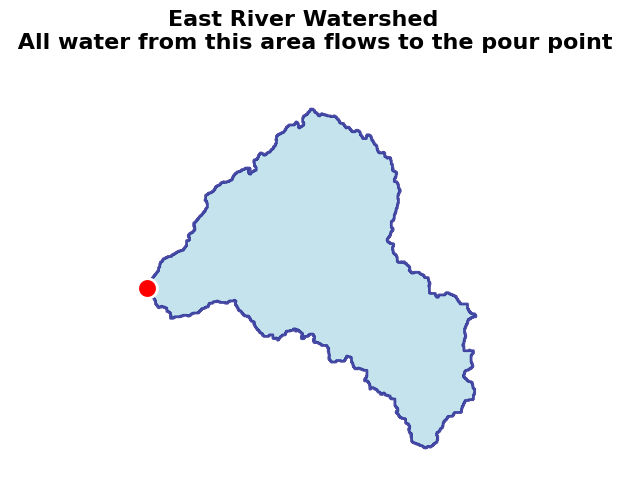

In [8]:
# Visualize the watershed
basin_path = project_dir / 'shapefiles' / 'river_basins'
if basin_path.exists():
    basin_files = list(basin_path.glob('*.shp'))
    
    if basin_files:
        fig, ax = plt.subplots(figsize=(6, 5))
        
        # Load watershed and pour point
        basin_gdf = gpd.read_file(basin_files[0])
        pour_point_gdf = gpd.read_file(pour_point_path)
        
        # Reproject for visualization
        basin_web = basin_gdf.to_crs(epsg=3857)
        pour_web = pour_point_gdf.to_crs(epsg=3857)
        
        # Plot watershed
        basin_web.plot(ax=ax, facecolor='lightblue', edgecolor='navy', 
                       linewidth=2, alpha=0.7)
        
        # Add pour point
        pour_web.plot(ax=ax, color='red', markersize=200, marker='o', 
                      edgecolor='white', linewidth=2, zorder=5)
                
        # Set extent
        minx, miny, maxx, maxy = basin_web.total_bounds
        pad = 5000
        ax.set_xlim(minx - pad, maxx + pad)
        ax.set_ylim(miny - pad, maxy + pad)
        
        ax.set_title('East River Watershed  \n All water from this area flows to the pour point', 
                    fontsize=16, fontweight='bold', pad=20)
        
        ax.axis('off')
        plt.tight_layout()
        plt.show()

## Step 3: Data Pipeline for Basin-Scale Streamflow Modeling
The same model-agnostic preprocessing framework now scales from point validation to basin-scale streamflow simulation. The core philosophy remains unchanged—standardized, quality-controlled data products—but the spatial context shifts from single locations to integrated watershed responses

In [21]:
# Execute streamflow data processing
confluence.managers['data'].process_observed_data()
print("✅ Streamflow data processing complete")

# Execute forcing acquisition (commented for demonstration)
# confluence.managers['data'].acquire_forcings()
print("✅ forcing acquisition complete (simulated)")

16:14:02 ● Processing observed data
16:14:02 ● Processing USGS streamflow data directly from API
16:14:02 ● Retrieving discharge data for station 11290000
16:14:02 ● Time period: 2016-01-02 to 2025-09-16
16:14:02 ● Converting from cfs to cms using factor: 0.0283168
16:14:02 ● Using formatted start date: 2016-01-02
16:14:02 ● Using formatted end date: 2025-09-16
16:14:02 ● Fetching data from: https://nwis.waterservices.usgs.gov/nwis/dv/?site=11290000&format=rdb&parameterCd=00060&startDT=2016-01-02&endDT=2025-09-16
16:14:02 ● Using discharge column: 9722_00060_00003
16:14:02 ● Using datetime column: datetime
16:14:04 ● Processed streamflow data saved to: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/observations/streamflow/preprocessed/Tuolumne_River_lumped_streamflow_processed.csv
16:14:04 ● Total rows in processed data: 85081
16:14:04 ● Number of non-null values: 85081
16:14:04 ● Number of null values: 0
16:14:04 ● Successfully processed USGS data for station 11290000


In [5]:
gdf = gpd.read_file("/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/catchment/Tuolumne_River_lumped_HRUs_GRUs_unique_ids.shp")

In [6]:
gdf

,ID,GRU_ID,gru_to_seg,GRU_area,HRU_ID,hru_type,elev_mean,center_lon,center_lat,HRU_area,hru_id_new,geometry
0,1,1,1,6.785192e+03,1,GRU,2795.300049,-119.444167,37.860000,6.785192e+03,1,"POLYGON ((-119.44458 37.86042, -119.44375 37.8..."
1,1,1,1,7.745086e+08,1,GRU,2847.684111,-119.407567,37.936709,7.745086e+08,2,"POLYGON ((-119.43125 38.11375, -119.42792 38.1..."


In [4]:
# Execute model-agnostic preprocessing
confluence.managers['data'].run_model_agnostic_preprocessing()
print("✅ Model-agnostic preprocessing complete")

10:29:13 ● Starting model-agnostic preprocessing
10:29:13 ● Running geospatial statistics


10:29:13 ● Starting geospatial statistics calculation
10:29:13 ● Soil statistics already calculated: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/catchment_intersection/with_soilgrids/catchment_with_soilclass.shp
10:29:13 ● Land statistics already calculated: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/catchment_intersection/with_landclass/catchment_with_landclass.shp
10:29:13 ● Elevation statistics already calculated: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/catchment_intersection/with_dem/catchment_with_dem.shp
10:29:13 ● Geospatial statistics completed: 3/3 steps skipped, 0/3 steps executed
10:29:13 ● Running forcing resampling
10:29:13 ● Starting forcing data resampling process
10:29:13 ● Creating ERA5 shapefile
10:29:13 ● Forcing shapefile already exists: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/forcing/forcing_ERA5.shp. Skipping creation.
10:29:13 ● Startin

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 774508622.73929703 of field GRU_area of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 774508622.73929703 of field HRU_area of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


10:29:13 ● Updated shapefile with unique IDs saved to: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/catchment/Tuolumne_River_lumped_HRUs_GRUs_unique_ids.shp
10:29:13 ● Fields in saved shapefile: ['ID', 'GRU_ID', 'gru_to_seg', 'GRU_area', 'HRU_ID', 'hru_type', 'elev_mean', 'center_lon', 'center_lat', 'HRU_area', 'hru_id_new', 'geometry']
10:29:13 ● Using field 'hru_id_new' from saved shapefile
10:29:13 ● Verification successful: All hru_id_new values are unique
10:29:13 ● Shapefile Tuolumne_River_lumped_HRUs_GRUs_unique_ids.shp already in WGS84
10:29:13 ● Worker 0: Working in temp directory: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/forcing/temp_easymore_308d7707_0
EASYMORE version 2.0.0 is initiated.
10:29:13 ● Worker 0: Creating new remap file...
EASYMORE is given multiple variables for remapping but only one format and fill value. EASYMORE repeats the format and fill value for all the variables in output files
EASYMORE will remap vari

The provided IDs in shapefile are not unique; provide unique IDs or do not identify target_shp_ID
Process ForkPoolWorker-15:
Process ForkPoolWorker-14:
Process ForkPoolWorker-13:
Process ForkPoolWorker-12:


KeyboardInterrupt: 

In [ ]:
# Execute model-specific preprocessing
confluence.managers['model'].preprocess_models()
print("✅ Basin-scale model configuration complete")

## Step 4: Streamlined Basin-Scale Model Execution
The same SUMMA process-based physics now scales from point validation to integrated basin simulation, but with the critical addition of streamflow routing. This represents a fundamental modeling advancement: from isolated vertical processes to coupled vertical-horizontal water transport that generates streamflow at the basin outlet.

In [ ]:
# Execute the integrated model system
confluence.managers['model'].run_models()
print("✅ Basin-scale integrated simulation complete")

## Step 5: Streamflow Evaluation and Basin Performance Assessment

In [ ]:
# Load observed streamflow data
obs_path = confluence.project_dir / "observations" / "streamflow" / "preprocessed" / f"{config_dict['DOMAIN_NAME']}_streamflow_processed.csv"
obs_df = pd.read_csv(obs_path, parse_dates=['datetime'])
obs_df.set_index('datetime', inplace=True)
    
# Load simulated streamflow from mizuRoute
summa_dir = confluence.project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "SUMMA"
routing_dir = confluence.project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "mizuRoute"
routing_files = list(routing_dir.glob("*.nc"))

if routing_files:
    # Load mizuRoute output
    routing_ds = xr.open_dataset(routing_files[0])
    
    # Extract streamflow variable (typically IRFroutedRunoff)
    sim_streamflow = routing_ds['IRFroutedRunoff']
    sim_df = sim_streamflow.to_pandas()    
    routing_ds.close()

else:
    sim_ds = xr.open_dataset(list(summa_dir.glob("*_timestep.nc"))[0])
    shp_file = gpd.read_file(str(confluence.project_dir / "shapefiles" / "catchment" / f"{config_dict['DOMAIN_NAME']}_HRUs_{config_dict['DOMAIN_DISCRETIZATION']}.shp"))
    shp_area = shp_file['GRU_area'].values[0]
    sim_ds['averageRoutedRunoff'] = sim_ds['averageRoutedRunoff'] * shp_area
    sim_streamflow = sim_ds['averageRoutedRunoff']    
    sim_df = sim_streamflow.to_pandas()
    
    sim_ds.close()

# =============================================================================
# STREAMFLOW PERFORMANCE EVALUATION
# =============================================================================

print(f"\n Streamflow Performance Assessment...")

# Align data to common period
start_date = max(obs_df.index.min(), sim_df.index.min())
end_date = min(obs_df.index.max(), sim_df.index.max())

# Skip initial spinup period
start_date = start_date + pd.DateOffset(months=6)

print(f"   Evaluation period: {start_date} to {end_date}")
print(f"   Duration: {(end_date - start_date).days} days")

# Filter to common period and resample to daily
obs_daily = obs_df['discharge_cms'].resample('D').mean().loc[start_date:end_date]
sim_daily = sim_df.resample('D').mean().loc[start_date:end_date]

# Ensure sim_daily is a Series (in case it's a DataFrame with one column)
if isinstance(sim_daily, pd.DataFrame):
    if sim_daily.shape[1] == 1:
        sim_daily = sim_daily.iloc[:, 0]  # Take the first (and likely only) column
    else:
        print(f"⚠️  sim_daily has {sim_daily.shape[1]} columns. Using the first column.")
        print(f"   Available columns: {list(sim_daily.columns)}")
        sim_daily = sim_daily.iloc[:, 0]

# Remove any remaining NaN values
valid_mask = ~(obs_daily.isna() | sim_daily.isna())
obs_valid = obs_daily[valid_mask]
sim_valid = sim_daily[valid_mask]    
print(f"   Valid paired observations: {len(obs_valid)} days")

# Calculate comprehensive performance metrics
print(f"\n📈 Streamflow Performance Metrics:")

# Basic statistics
rmse = np.sqrt(((obs_valid - sim_valid) ** 2).mean())
bias = (sim_valid - obs_valid).mean()
mae = np.abs(obs_valid - sim_valid).mean()

# Relative metrics
pbias = 100 * bias / obs_valid.mean()

# Nash-Sutcliffe Efficiency
nse = 1 - ((obs_valid - sim_valid) ** 2).sum() / ((obs_valid - obs_valid.mean()) ** 2).sum()

# Kling-Gupta Efficiency  
r = obs_valid.corr(sim_valid)
alpha = sim_valid.std() / obs_valid.std()
beta = sim_valid.mean() / obs_valid.mean()
kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# Display performance metrics
print(f"   📊 RMSE: {rmse:.2f} m³/s")
print(f"   📊 Bias: {bias:+.2f} m³/s ({pbias:+.1f}%)")
print(f"   📊 MAE: {mae:.2f} m³/s")
print(f"   📊 Correlation (r): {r:.3f}")
print(f"   📊 Nash-Sutcliffe (NSE): {nse:.3f}")
print(f"   📊 Kling-Gupta (KGE): {kge:.3f}")

# Hydrologic signature analysis
print(f"\n🌊 Hydrologic Signature Analysis:")

# Flow statistics
obs_q95 = obs_valid.quantile(0.95)  # High flows
sim_q95 = sim_valid.quantile(0.95)
obs_q05 = obs_valid.quantile(0.05)  # Low flows  
sim_q05 = sim_valid.quantile(0.05)

print(f"   High flows (Q95): Obs={obs_q95:.1f}, Sim={sim_q95:.1f} m³/s")
print(f"   Low flows (Q05): Obs={obs_q05:.1f}, Sim={sim_q05:.1f} m³/s")

# Seasonal timing
obs_monthly = obs_valid.groupby(obs_valid.index.month).mean()
sim_monthly = sim_valid.groupby(sim_valid.index.month).mean()
peak_month_obs = obs_monthly.idxmax()
peak_month_sim = sim_monthly.idxmax()

print(f"   Peak flow timing: Obs=Month {peak_month_obs}, Sim=Month {peak_month_sim}")

# =============================================================================
# STREAMFLOW VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Time series comparison (top left)
ax1 = axes[0, 0]
ax1.plot(obs_valid.index, obs_valid.values, 'b-', 
         label='WSC Observed', linewidth=1.5, alpha=0.8)
ax1.plot(sim_valid.index, sim_valid.values, 'r-', 
         label='SUMMA + mizuRoute', linewidth=1.5, alpha=0.8)

ax1.set_ylabel('Discharge (m³/s)', fontsize=11)
ax1.set_title('Streamflow Time Series', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add performance metrics
metrics_text = f'NSE: {nse:.3f}\nKGE: {kge:.3f}\nBias: {pbias:+.1f}%'
ax1.text(0.02, 0.95, metrics_text, transform=ax1.transAxes,
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10, verticalalignment='top')

# Scatter plot (top right)
ax2 = axes[0, 1]
ax2.scatter(obs_valid, sim_valid, alpha=0.5, c='blue', s=20)
max_val = max(obs_valid.max(), sim_valid.max())
ax2.plot([0, max_val], [0, max_val], 'k--', label='1:1 line')
ax2.set_xlabel('Observed (m³/s)', fontsize=11)
ax2.set_ylabel('Simulated (m³/s)', fontsize=11)
ax2.set_title('Obs vs Sim Streamflow', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Monthly climatology (bottom left)
ax3 = axes[1, 0]
months = range(1, 13)
month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

ax3.plot(months, obs_monthly.values, 'o-', label='Observed', 
         color='blue', linewidth=2, markersize=6)
ax3.plot(months, sim_monthly.values, 'o-', label='Simulated', 
         color='red', linewidth=2, markersize=6)

ax3.set_xticks(months)
ax3.set_xticklabels(month_names)
ax3.set_ylabel('Mean Discharge (m³/s)', fontsize=11)
ax3.set_title('Seasonal Flow Regime', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Flow duration curve (bottom right)
ax4 = axes[1, 1]

# Calculate exceedance probabilities
obs_sorted = obs_valid.sort_values(ascending=False)
sim_sorted = sim_valid.sort_values(ascending=False)
obs_ranks = np.arange(1., len(obs_sorted) + 1) / len(obs_sorted) * 100
sim_ranks = np.arange(1., len(sim_sorted) + 1) / len(sim_sorted) * 100

ax4.semilogy(obs_ranks, obs_sorted, 'b-', label='Observed', linewidth=2)
ax4.semilogy(sim_ranks, sim_sorted, 'r-', label='Simulated', linewidth=2)

ax4.set_xlabel('Exceedance Probability (%)', fontsize=11)
ax4.set_ylabel('Discharge (m³/s)', fontsize=11)
ax4.set_title('Flow Duration Curve', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Basin-Scale Streamflow Evaluation - {config_dict["DOMAIN_NAME"]}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary: Lumped Basin-Scale Streamflow Simulation
This tutorial successfully demonstrated the critical scaling transition from point-scale process validation to basin-scale integrated streamflow simulation using CONFLUENCE. Through the Bow River at Banff case study, we illustrated how the same standardized workflow framework seamlessly scales from individual site validation to watershed-scale prediction while maintaining scientific rigor and computational efficiency.

## Key Methodological Achievements
The tutorial established watershed-scale modeling capabilities by successfully transitioning from point measurements to integrated basin response through automated watershed delineation and lumped representation strategies. Spatial aggregation techniques were demonstrated through catchment-averaged characteristic development that captures essential watershed properties while maintaining computational tractability. Integrated process simulation was achieved by coupling SUMMA's process-based physics with mizuRoute streamflow routing to transform distributed runoff generation into streamflow predictions at the basin outlet.

## Scientific Process Understanding
The evaluation demonstrated CONFLUENCE's ability to simulate integrated watershed response through the successful representation of snow accumulation, melt, and runoff generation processes across elevation gradients in a mountain environment. Seasonal flow regime capture was validated through comparison with long-term Water Survey of Canada observations, showing the model's capability to represent pronounced spring freshet patterns and low-flow periods. Water balance closure was maintained through conservation of mass principles while scaling from point processes to basin-integrated streamflow generation.

## Framework Scalability Validation
This tutorial confirmed CONFLUENCE's seamless scaling capabilities by applying identical workflow principles from point validation through basin-scale prediction without requiring fundamental architectural changes. The model-agnostic preprocessing approach proved equally effective for basin-averaged forcing and validation data preparation, reinforcing the framework's broad applicability. Computational efficiency was demonstrated through lumped representation strategies that enable rapid execution suitable for calibration, uncertainty analysis, and operational applications while maintaining process-based physical realism.

This foundation in lumped basin modeling establishes the essential principles for understanding watershed-scale hydrological behavior and 
prepares for the spatial complexity introduced in semi-distributed and fully distributed modeling approaches in subsequent tutorials.

### Next Focus: Semi-Distributed Watershed Modelling 

**Ready to explore Semi-Distributed basin simulations?** → **[Tutorial 02b: Basin Scale - Semi-Distributed Watershed](./02b_basin_semi_distributed.ipynb)**